In [2]:
import pandas as pd 
read = pd.read_csv('Traffic.csv', encoding='latin1')
df = pd.DataFrame(read)
df = df.rename(columns={'Day of the week': 'Day_of_week'})
# print(read.info())
#HAMDLING DATA
# print(df.isnull().sum())
# print(df.dtypes)
# print(df.Time)
df["Time"] = pd.to_datetime(df["Time"], errors='coerce')
df["Date"] = pd.to_datetime(df["Date"], errors='coerce')  

# print(df.dtypes)
def hello():
    print("HEllo world")

In [3]:

#ANALYZING DATA
#day by finding
X = day_analysis = df.groupby("Day_of_week")["Total"].agg(['max', 'min'])


# hour by finding 
df["Hour"] = df["Time"].dt.hour
hour = df.groupby("Hour")["Total"].mean().astype(int)

# TIme by finding
y = time_analysis = df.groupby("Hour")["Total"].agg(['max', 'min'])


#vehicle by finding 
print(df[["CarCount","BikeCount","BusCount","TruckCount","Total"]].corr().round(3)["Total"].sort_values(ascending=False))
#Now situalation wise 
Traffic_situ_day = df.groupby("Day_of_week")["Traffic Situation"].value_counts()
Traffic_situ_hour = df.groupby("Hour")["Traffic Situation"].value_counts()



Total         1.000
CarCount      0.970
BikeCount     0.797
BusCount      0.791
TruckCount   -0.555
Name: Total, dtype: float64


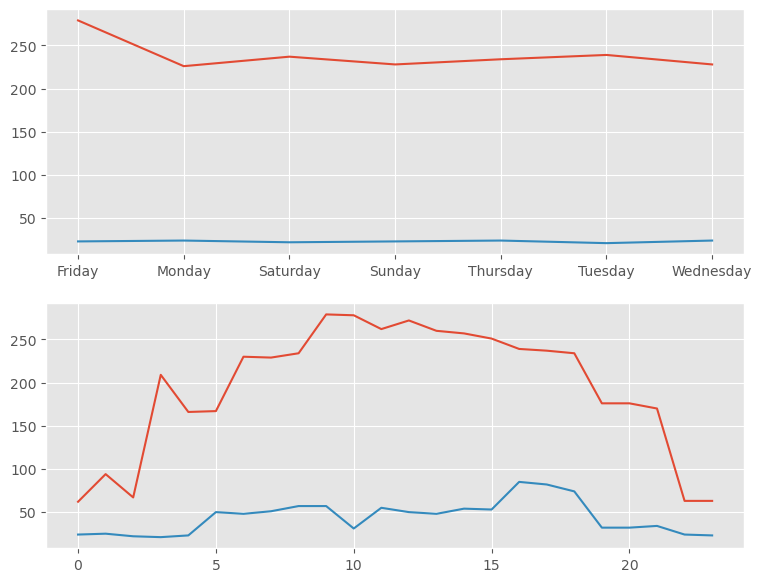

hello


In [8]:
import matplotlib.pyplot as plt
#USING MATPLOTLIB
plt.style.use("ggplot")
plt.figure(figsize=(9, 7))
plt.tight_layout()
plt.subplot(2,1,1)

plt.plot(day_analysis)
plt.subplot(2,1,2)
plt.plot(time_analysis)
plt.show()




if __name__ == "__main__":
    print("hello")



In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[[
    "Hour",
    "CarCount",
    "BikeCount",
    "BusCount",
    "TruckCount"
]]

y = df["Total"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

score = model.score(X_test, y_test)

print("Accuracy:", round(score * 100, 2), "%")

Accuracy: 100.0 %
